# Investigation 02 - 4D Metric Correlation Bubble Plot


In [116]:
import ast
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [117]:
# ---------- Main toggles ----------
METHOD = "CN"
ORGAN = "Colon"   # "Colon", "Duodenum", or None
ORGAN_COLUMN = "Organ"
NO_SELF = False
SUBSET_RULE_ITEMS_EQ = 2
SUBSET_MIN_SUPPORT = 0.03
STAGE_COLUMN = "Pathological stage"
FDR_COLUMN = "FDR"
FDR_MAX = 0.05

# ---------- Bubble thresholds ----------
POS_LEVERAGE_MIN = 0.05
POS_LOG2_LIFT_MIN = 1.3
NEG_LEVERAGE_MAX = -0.05
NEG_LOG2_LIFT_MAX = -1.0

# ---------- Bubble display ----------
MIN_SUPPORT_FOR_BUBBLE = 0.0
BUBBLE_SIZE_SCALE = 2000
NOISE_LEVERAGE_ABS = 0.01
NOISE_LOG2_LIFT_ABS = 0.2

# ---------- Data path ----------
DATA_ROOT = r"results\full_run\weighted_fpgrowth\data"
RAW_RESULTS_FILE = os.path.join("..", "..", DATA_ROOT, f"results_{METHOD}.csv")

print("METHOD:", METHOD)
print("ORGAN:", ORGAN)
print("NO_SELF:", NO_SELF)
print("SUBSET_RULE_ITEMS_EQ:", SUBSET_RULE_ITEMS_EQ)
print("SUBSET_MIN_SUPPORT:", SUBSET_MIN_SUPPORT)
print("STAGE_RANGE:", (STAGE_MIN, STAGE_MAX))
print("FDR_MAX:", FDR_MAX)
print("RAW_RESULTS_FILE:", RAW_RESULTS_FILE)


METHOD: CN
ORGAN: Colon
NO_SELF: False
SUBSET_RULE_ITEMS_EQ: 2
SUBSET_MIN_SUPPORT: 0.03
STAGE_RANGE: (0, 0)
FDR_MAX: 0.05
RAW_RESULTS_FILE: ..\..\results\full_run\weighted_fpgrowth\data\results_CN.csv


In [118]:
def _plot_metric_bubble(metric_df, leverage_source):
    if metric_df.empty:
        print("No rows after filtering. Adjust filters or thresholds.")
        return None

    fig, ax = plt.subplots(figsize=(14, 10))

    scatter = ax.scatter(
        metric_df["Leverage"],
        metric_df["Log2_Lift"],
        s=metric_df["Bubble_Size"],
        c=metric_df["Confidence"],
        cmap="viridis",
        alpha=0.75,
        edgecolors="black",
        linewidths=0.3,
    )

    ax.axvline(0, color="gray", linewidth=1.0)
    ax.axhline(0, color="gray", linewidth=1.0)
    ax.axvline(POS_LEVERAGE_MIN, color="tomato", linestyle="--", linewidth=1.0)
    ax.axhline(POS_LOG2_LIFT_MIN, color="tomato", linestyle="--", linewidth=1.0)
    ax.axvline(NEG_LEVERAGE_MAX, color="royalblue", linestyle="--", linewidth=1.0)
    ax.axhline(NEG_LOG2_LIFT_MAX, color="royalblue", linestyle="--", linewidth=1.0)

    x_min, x_max = metric_df["Leverage"].min(), metric_df["Leverage"].max()
    y_min, y_max = metric_df["Log2_Lift"].min(), metric_df["Log2_Lift"].max()

    if x_max > POS_LEVERAGE_MIN and y_max > POS_LOG2_LIFT_MIN:
        pos_rect = Rectangle(
            (POS_LEVERAGE_MIN, POS_LOG2_LIFT_MIN),
            x_max - POS_LEVERAGE_MIN,
            y_max - POS_LOG2_LIFT_MIN,
            fill=False,
            edgecolor="tomato",
            linewidth=1.2,
        )
        ax.add_patch(pos_rect)

    if x_min < NEG_LEVERAGE_MAX and y_min < NEG_LOG2_LIFT_MAX:
        neg_rect = Rectangle(
            (x_min, y_min),
            NEG_LEVERAGE_MAX - x_min,
            NEG_LOG2_LIFT_MAX - y_min,
            fill=False,
            edgecolor="royalblue",
            linewidth=1.2,
        )
        ax.add_patch(neg_rect)

    colorbar = plt.colorbar(scatter, ax=ax)
    colorbar.set_label("Confidence")

    supports = metric_df["Support"].quantile([0.1, 0.5, 0.75, 0.9]).values
    handles = [
        ax.scatter([], [], s=max(s * BUBBLE_SIZE_SCALE, 10), color="gray", alpha=0.35, edgecolors="none")
        for s in supports
    ]
    labels = [f"Support {s:.3f}" for s in supports]
    ax.legend(handles, labels, title="Bubble size", loc="upper left")

    positive_count = int(((metric_df["Leverage"] >= POS_LEVERAGE_MIN) & (metric_df["Log2_Lift"] >= POS_LOG2_LIFT_MIN)).sum())
    negative_count = int(((metric_df["Leverage"] <= NEG_LEVERAGE_MAX) & (metric_df["Log2_Lift"] <= NEG_LOG2_LIFT_MAX)).sum())
    dot_count = int(metric_df.shape[0])

    if STAGE_MIN is not None and STAGE_MAX is not None:
        stage_text = f"Stages {STAGE_MIN} to {STAGE_MAX} (0=control)"
    elif STAGE_MIN is not None:
        stage_text = f"Stages >= {STAGE_MIN} (0=control)"
    elif STAGE_MAX is not None:
        stage_text = f"Stages <= {STAGE_MAX} (0=control)"
    else:
        stage_text = "All stages"

    organ_text = ORGAN if ORGAN is not None else "All"
    ax.set_title(
        f"4D Metric Correlation Bubble Plot ({METHOD}) - {organ_text}\n"
        f"{stage_text} | FDR < {FDR_MAX}, Leverage source: {leverage_source}"
    )
    ax.set_xlabel("Leverage")
    ax.set_ylabel("log2(Lift)")
    ax.text(
        0.01,
        -0.12,
        f"Dots: {dot_count} | Positive: {positive_count} | Negative: {negative_count}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
    )
    fig.subplots_adjust(bottom=0.16)

    return fig


def _summarize_threshold_zones(metric_df):
    positive_zone = (metric_df["Leverage"] >= POS_LEVERAGE_MIN) & (metric_df["Log2_Lift"] >= POS_LOG2_LIFT_MIN)
    negative_zone = (metric_df["Leverage"] <= NEG_LEVERAGE_MAX) & (metric_df["Log2_Lift"] <= NEG_LOG2_LIFT_MAX)
    noise_zone = (metric_df["Leverage"].abs() <= NOISE_LEVERAGE_ABS) & (metric_df["Log2_Lift"].abs() <= NOISE_LOG2_LIFT_ABS)

    summary = pd.DataFrame(
        {
            "Zone": ["Positive zone", "Negative zone", "Noise zone", "Total"],
            "Count": [int(positive_zone.sum()), int(negative_zone.sum()), int(noise_zone.sum()), int(metric_df.shape[0])],
        }
    )
    summary["Percent"] = (summary["Count"] / max(metric_df.shape[0], 1) * 100).round(2)
    return summary


### Load Raw Data

In [119]:
raw_results_df = pd.read_csv(RAW_RESULTS_FILE)
print("raw_results_df:", raw_results_df.shape)
raw_results_df.head(3)


raw_results_df: (209516, 22)


,FOV,Antecedents,Consequents,Lift,Confidence,Conviction,Support,P_Value,FDR,Rule_Count_Global,...,Cortico Response,Survival at follow-up,GI stage,Grade GVHD,liver stage,skin stage,Pathological stage,Clinical score,Pathological score,Group
0,Control_01_FOV_1,"['CD8T_CD103+_NEIGHBOR', 'CD8T_CD69+_CENTER', ...","['CD8T_CD103+_CENTER', 'Epithelial_NEIGHBOR']",45.993316,0.877821,8.028498,0.01325,0.175824,0.308193,2,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0
1,Control_01_FOV_1,"['CD8T_CD103+_CENTER', 'Epithelial_NEIGHBOR']","['CD8T_CD103+_NEIGHBOR', 'CD8T_CD69+_CENTER', ...",45.993316,0.694208,3.220842,0.01325,0.175824,0.308193,5,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0
2,Control_01_FOV_1,"['CD8T_CD103+_NEIGHBOR', 'CD8T_CD69+_CENTER', ...","['CD8T_CD103+_CENTER', 'Epithelial_HLADRDPDQ+_...",44.419467,0.804351,5.018646,0.01325,0.175824,0.308193,3,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0


### Build Filtered Bubble Table

In [129]:
def _to_lineage(cell_label):
    cell_label = str(cell_label)
    if cell_label.endswith("+") and "_" in cell_label:
        return cell_label.rsplit("_", 1)[0]
    return cell_label


def _create_basic_dataset(raw_results_df):
    work_df = raw_results_df.copy()

    # --- Standardized Organ Enrichment (Inlined from visualization_util logic) ---
    mibi_gut_dir_path = os.path.join("..", "..", "data", "MIBIGutCsv")
    biopsy_path = os.path.join(mibi_gut_dir_path, "biopsy_metadata.csv")
    fovs_path = os.path.join(mibi_gut_dir_path, "fovs_metadata.csv")
    
    if os.path.exists(biopsy_path) and os.path.exists(fovs_path):
        df_biopsy = pd.read_csv(biopsy_path)
        df_fovs = pd.read_csv(fovs_path)
        unique_biopsies = df_fovs[~df_fovs["FOV"].astype(str).str.startswith("S_")][["Patient", "Cohort"]].drop_duplicates().rename(columns={"Patient": "Biopsy_ID"})
        meta = pd.merge(unique_biopsies, df_biopsy[["Biopsy_ID", "Localization"]], on="Biopsy_ID", how="left")
        
        def get_organ(row):
            if pd.notna(row.get("Localization")): return row["Localization"]
            cohort = str(row.get("Cohort", ""))
            if "Colon" in cohort: return "Colon"
            if "Duodenum" in cohort: return "Duodenum"
            return "Unknown"
        
        meta["Organ"] = meta.apply(get_organ, axis=1)
        work_df = work_df.merge(meta[["Biopsy_ID", "Organ"]], on="Biopsy_ID", how="left")
    # -----------------------------------------------------------------------------

    work_df["ant_items"] = work_df["Antecedents"].apply(ast.literal_eval)
    work_df["con_items"] = work_df["Consequents"].apply(ast.literal_eval)
    work_df["ant_clean"] = work_df["ant_items"].apply(
        lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items]
    )
    work_df["con_clean"] = work_df["con_items"].apply(
        lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items]
    )
    work_df["ant_lineage"] = work_df["ant_clean"].apply(lambda items: [_to_lineage(x) for x in items])
    work_df["con_lineage"] = work_df["con_clean"].apply(lambda items: [_to_lineage(x) for x in items])
    print(f"Initial rules count: {work_df.shape[0]}")

    if NO_SELF:
        has_overlap = work_df.apply(
            lambda row: len(set(row["ant_lineage"]).intersection(set(row["con_lineage"]))) > 0,
            axis=1,
        )
        work_df = work_df[~has_overlap].copy()
        print(f"Rules count after removing self-overlapping rules: {work_df.shape[0]}")

    if SUBSET_RULE_ITEMS_EQ is not None:
        rule_item_count = work_df.apply(lambda row: len(row["ant_clean"]) + len(row["con_clean"]), axis=1)
        work_df = work_df[rule_item_count == int(SUBSET_RULE_ITEMS_EQ)].copy()
        print(f"Rules count after filtering by subset rule items: {work_df.shape[0]}")

    if SUBSET_MIN_SUPPORT is not None:
        work_df = work_df[work_df["Support"] >= float(SUBSET_MIN_SUPPORT)].copy()
        print(f"Rules count after filtering by minimum support: {work_df.shape[0]}")

    stage_values = pd.to_numeric(work_df[STAGE_COLUMN], errors="coerce")
    if STAGE_MIN is not None:
        work_df = work_df[stage_values >= float(STAGE_MIN)].copy()
        stage_values = pd.to_numeric(work_df[STAGE_COLUMN], errors="coerce")
        print(f"Rules count after filtering by minimum stage: {work_df.shape[0]}")

    if STAGE_MAX is not None:
        work_df = work_df[stage_values <= float(STAGE_MAX)].copy()
        print(f"Rules count after filtering by stage: {work_df.shape[0]}")

    if ORGAN is not None:
        work_df = work_df[work_df["Organ"].astype(str) == str(ORGAN)].copy()
        print(f"Rules count after filtering by organ: {work_df.shape[0]}")

    # --- Safeguard --- 
    if work_df.empty:
        print("Dataset is empty after filtering! Returning early.")
        return work_df
    # -----------------

    work_df["Rule"] = work_df.apply(
        lambda row: f"{', '.join(row['ant_clean'])} -> {', '.join(row['con_clean'])}",
        axis=1,
    )

    return work_df


def _build_metric_bubble_df(work_df):

    if work_df.empty:
        print("Input work_df is empty. Returning empty metric_df.")
        raise ValueError("Input work_df is empty. Cannot build metric_df.")

    metric_df = work_df.copy()
    metric_df = metric_df[metric_df[FDR_COLUMN] < FDR_MAX].copy()
    
    # Defensive checks on the base metrics used in the plot
    metric_df = metric_df[np.isfinite(metric_df["Lift"])].copy()
    metric_df = metric_df[np.isfinite(metric_df["Confidence"])].copy()
    metric_df = metric_df[np.isfinite(metric_df["Support"])].copy()
    metric_df = metric_df[metric_df["Lift"] > 0].copy()

    # 1. Calculate per-FOV metrics FIRST
    # leverage = support - expected_support, and expected_support = support / lift
    metric_df["Leverage"] = metric_df["Support"] * (1 - 1 / metric_df["Lift"])
    metric_df["Log2_Lift"] = np.log2(metric_df["Lift"])
    
    # Defensive checks on the derived metrics
    metric_df = metric_df[np.isfinite(metric_df["Leverage"])].copy()
    metric_df = metric_df[np.isfinite(metric_df["Log2_Lift"])].copy()

    # 2. THEN group by Rule to get the true mathematical mean of all values
    print("metric_df number of lines:", metric_df.shape[0])
    metric_df = metric_df.groupby("Rule", as_index=False)[
        ["Lift", "Confidence", "Support", "Leverage", "Log2_Lift", FDR_COLUMN]
    ].mean()

    # 3. Apply final display filters
    metric_df = metric_df[metric_df["Support"] >= MIN_SUPPORT_FOR_BUBBLE].copy()
    metric_df["Bubble_Size"] = (metric_df["Support"] * BUBBLE_SIZE_SCALE).clip(lower=10)
    
    leverage_source = "mean of per-FOV Leverage"

    return metric_df, leverage_source


Initial rules count: 209516
Rules count after filtering by subset rule items: 5130
Rules count after filtering by minimum support: 1158
Rules count after filtering by minimum stage: 1158
Rules count after filtering by stage: 298
Rules count after filtering by organ: 151
filtered work_df: (151, 30)
metric_df (after FDR + metric filters): (38, 8)
leverage_source: mean of per-FOV Leverage
                        Rule      Lift  Confidence   Support  Leverage  \
0             Bcell -> Bcell  7.499054    0.933545  0.035594  0.030848   
1              Bcell -> CD4T  3.510580    0.849001  0.032371  0.023150   
2         Epithelial -> CD4T  0.612811    0.233116  0.038525 -0.024541   
3   Epithelial -> CD4T_CD69+  0.680154    0.219583  0.031753 -0.015590   
4         Epithelial -> CD8T  0.719554    0.282511  0.045627 -0.018067   
5  Epithelial -> Endothelial  0.508457    0.103315  0.034566 -0.033416   
6   Epithelial -> Macrophage  0.725183    0.504871  0.072713 -0.027250   
7       Epithelial 

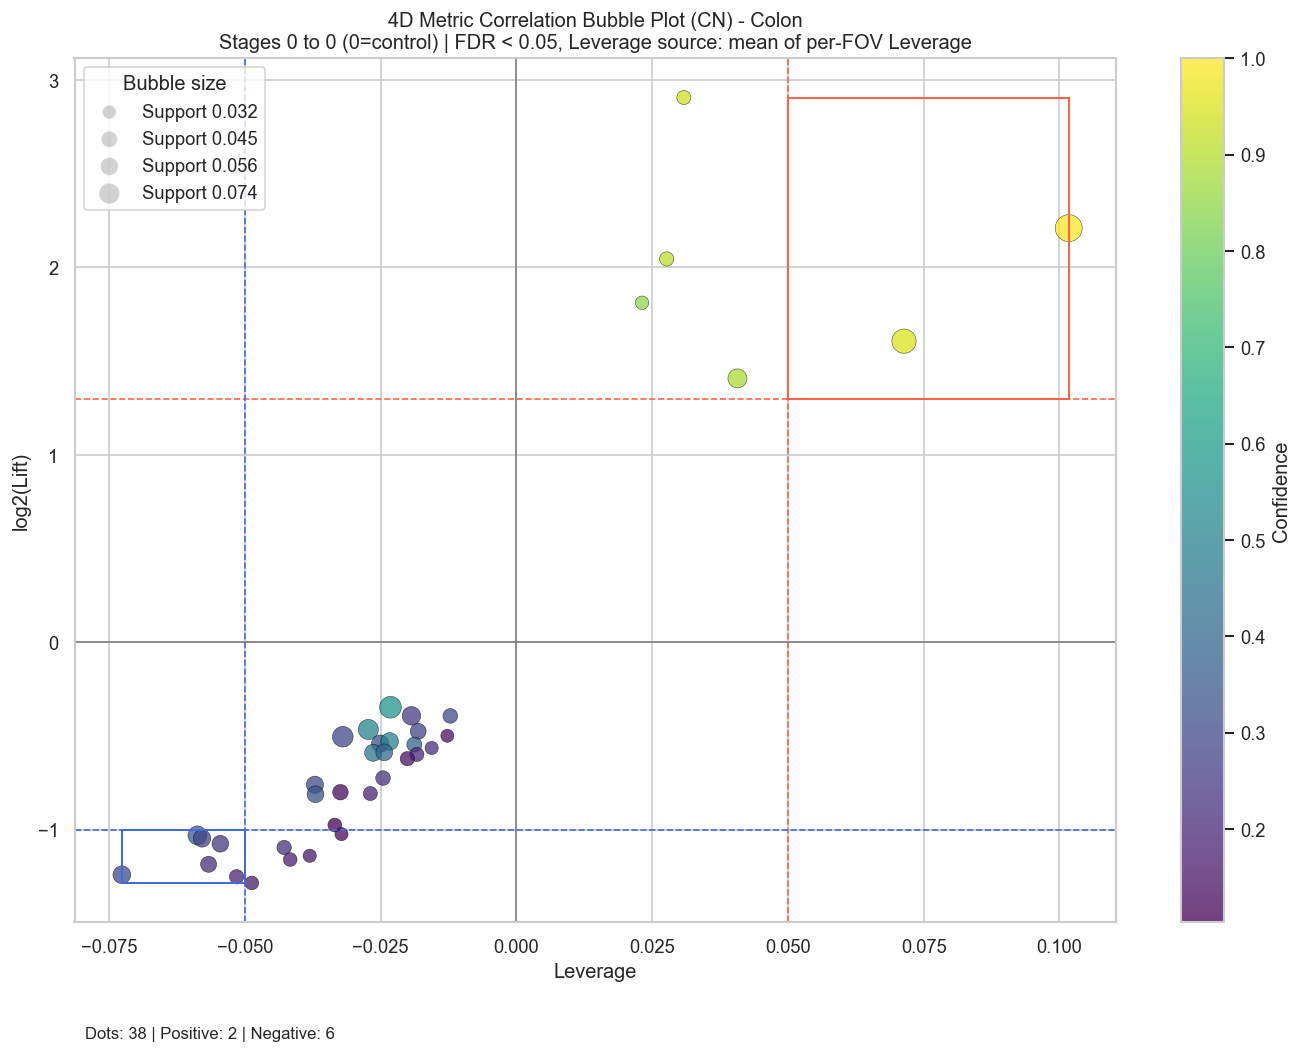

In [125]:
STAGE_MIN = 0   # 0 is control
STAGE_MAX = 0
ORGAN = "Colon" 
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()


Initial rules count: 209516
Rules count after filtering by subset rule items: 5130
Rules count after filtering by minimum support: 1158
Rules count after filtering by minimum stage: 1158
Rules count after filtering by stage: 298
Rules count after filtering by organ: 57
metric_df number of lines: 53
filtered work_df: (57, 30)
metric_df (after FDR + metric filters): (23, 8)
leverage_source: mean of per-FOV Leverage
                         Rule      Lift  Confidence   Support  Leverage  \
0        Bcell -> Plasma_CD38  0.429775    0.064635  0.033575 -0.044547   
1  BrunnerGland -> Macrophage  0.664130    0.427031  0.044380 -0.022444   
2          Epithelial -> CD4T  0.530012    0.248285  0.065022 -0.057983   
3   Epithelial -> CD4T_CD103+  0.343785    0.115230  0.031158 -0.059475   
4    Epithelial -> CD4T_CD69+  0.503084    0.195754  0.052887 -0.053125   
5    Epithelial -> CD4T_Ki67+  0.495022    0.084331  0.030209 -0.030816   
6    Epithelial -> CD8T_CD69+  0.482097    0.123235  0.043

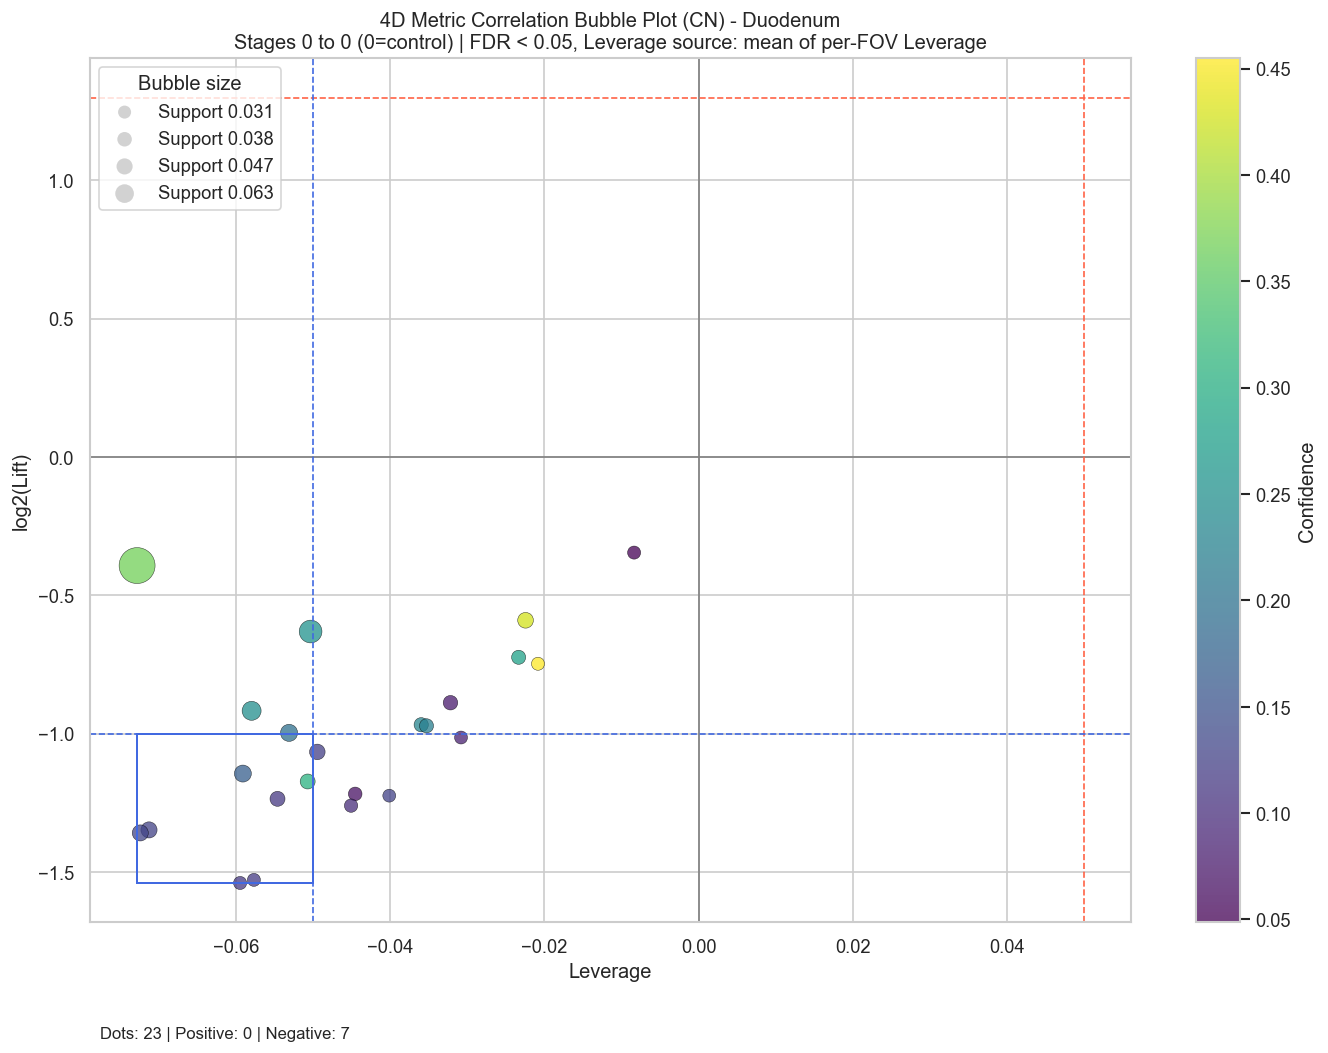

In [133]:
STAGE_MIN = 0   # 0 is control
STAGE_MAX = 0
ORGAN = "Duodenum" 
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()


In [122]:
zone_summary_df = _summarize_threshold_zones(metric_df)
display(zone_summary_df)

print('\nMean values of the wanted subset:')
display(metric_df[["Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]].mean().to_frame(name="Mean"))


,Zone,Count,Percent
0,Positive zone,2,5.26
1,Negative zone,6,15.79
2,Noise zone,0,0.00
3,Total,38,100.00



Mean values of the wanted subset:


,Mean
Leverage,-0.020193
Lift,1.172109
Log2_Lift,-0.344544
Confidence,0.375037
Support,0.050317


Initial rules count: 209516
Rules count after filtering by subset rule items: 5130
Rules count after filtering by minimum support: 1158
Rules count after filtering by minimum stage: 860
Rules count after filtering by stage: 629
Rules count after filtering by organ: 284
filtered work_df: (284, 30)
metric_df (after FDR + metric filters): (65, 8)
leverage_source: mean of per-FOV Leverage
                       Rule      Lift  Confidence   Support  Leverage  \
0            CD4T -> Goblet  0.481965    0.307727  0.042420 -0.044879   
1         Epithelial -> APC  0.656834    0.154835  0.046237 -0.024276   
2        Epithelial -> CD4T  0.611263    0.194924  0.048787 -0.031912   
3  Epithelial -> CD4T_CD69+  0.579011    0.155943  0.046261 -0.035212   
4  Epithelial -> CD4T_Ki67+  0.482287    0.096259  0.037091 -0.039815   
5        Epithelial -> CD8T  0.650917    0.215031  0.043546 -0.023070   
6  Epithelial -> CD8T_CD69+  0.521068    0.110892  0.042729 -0.039274   
7  Epithelial -> CD8T_GZMB+ 

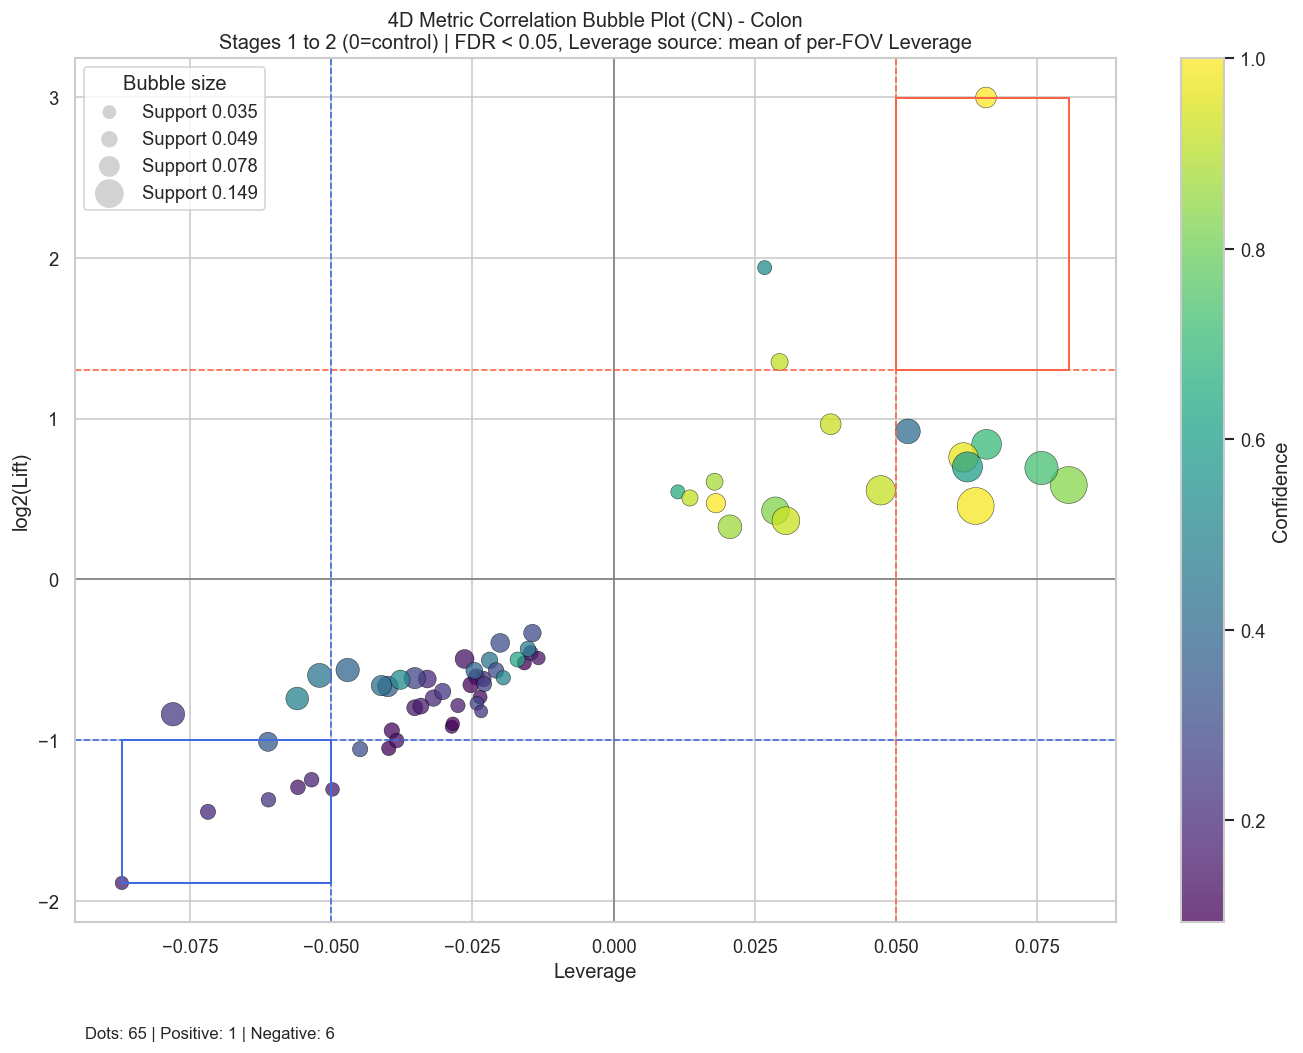

In [ ]:
STAGE_MIN = 1   # 0 is control
STAGE_MAX = 2
organ = "Colon"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()


Initial rules count: 209516
Rules count after filtering by subset rule items: 5130
Rules count after filtering by minimum support: 1158
Rules count after filtering by minimum stage: 860
Rules count after filtering by stage: 629
Rules count after filtering by organ: 345
metric_df number of lines: 326
filtered work_df: (345, 30)
metric_df (after FDR + metric filters): (85, 8)
leverage_source: mean of per-FOV Leverage
                                    Rule      Lift  Confidence   Support  \
0           BrunnerGland -> BrunnerGland  3.866422    0.992400  0.090985   
1             BrunnerGland -> Epithelial  0.409351    0.249457  0.053184   
2  BrunnerGland -> Epithelial_HLADRDPDQ+  0.419323    0.183231  0.039065   
3             BrunnerGland -> Fibroblast  0.751940    0.706546  0.073776   
4             BrunnerGland -> Macrophage  0.569681    0.444679  0.039743   
5                   BrunnerGland -> Mast  0.798731    0.243162  0.030886   
6                 BrunnerGland -> Neuron  0.67102

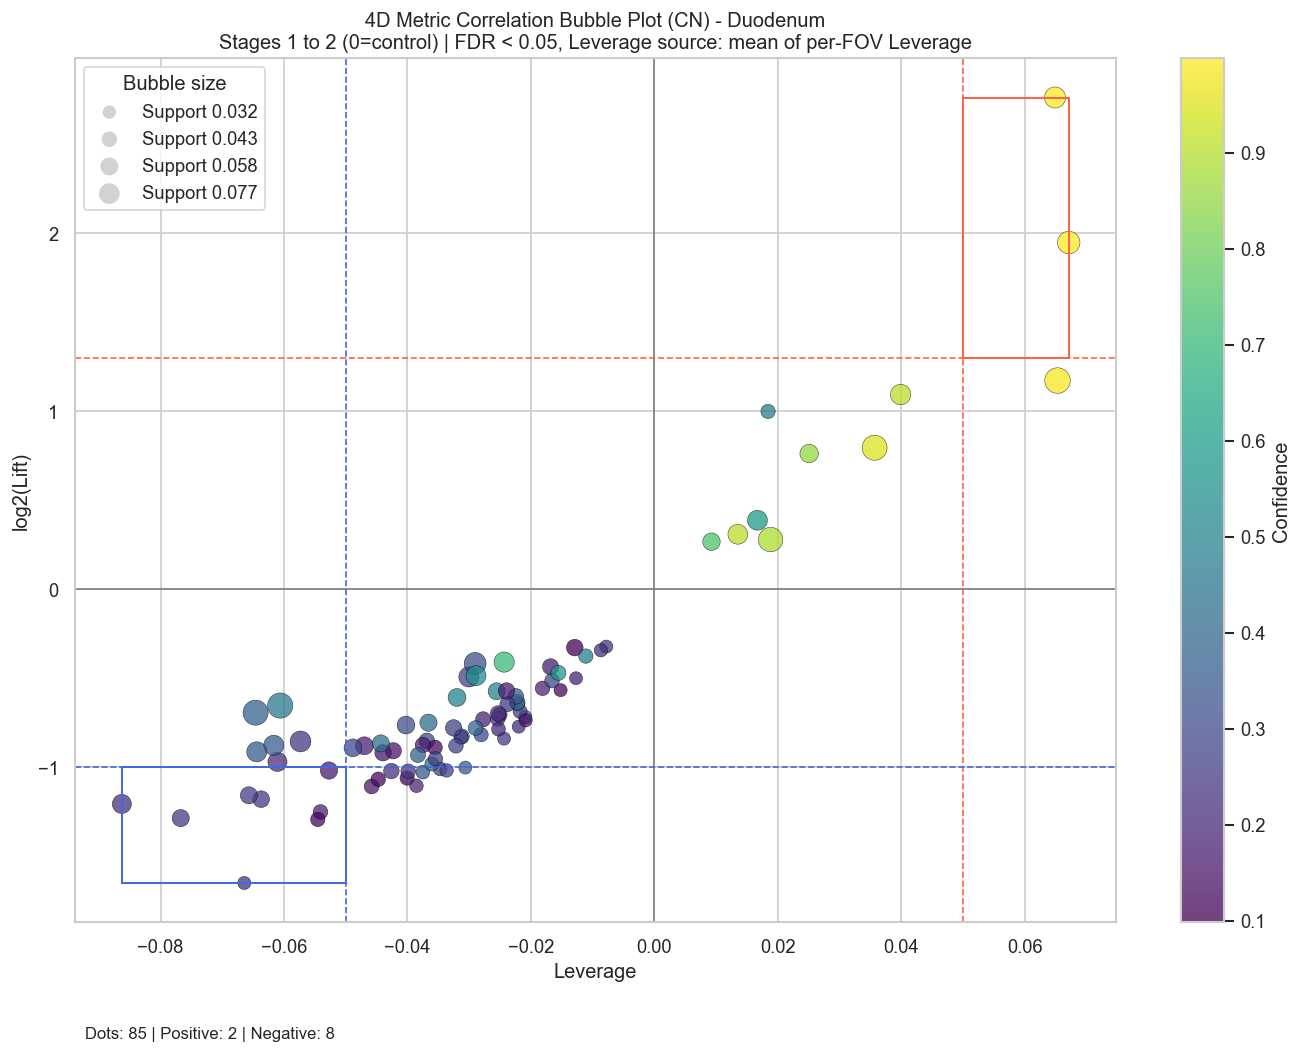

In [134]:
STAGE_MIN = 1   # 0 is control
STAGE_MAX = 2
organ = "Duodenum"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()


Initial rules count: 209516
Rules count after filtering by subset rule items: 5130
Rules count after filtering by minimum support: 1158
Rules count after filtering by minimum stage: 231
Rules count after filtering by stage: 231
Rules count after filtering by organ: 99
metric_df number of lines: 94
filtered work_df: (99, 30)
metric_df (after FDR + metric filters): (38, 8)
leverage_source: mean of per-FOV Leverage
                              Rule      Lift  Confidence   Support  Leverage  \
0               Epithelial -> CD4T  0.506371    0.159008  0.044550 -0.044131   
1         Epithelial -> CD4T_CD69+  0.528266    0.148444  0.036190 -0.032681   
2               Epithelial -> CD8T  0.629337    0.228564  0.042049 -0.026620   
3         Epithelial -> CD8T_GZMB+  0.553400    0.219918  0.034102 -0.029996   
4        Epithelial -> Endothelial  0.632220    0.092042  0.031280 -0.018196   
5    Epithelial -> Macrophage_Calp  0.502594    0.104432  0.037493 -0.037106   
6             Epithelial

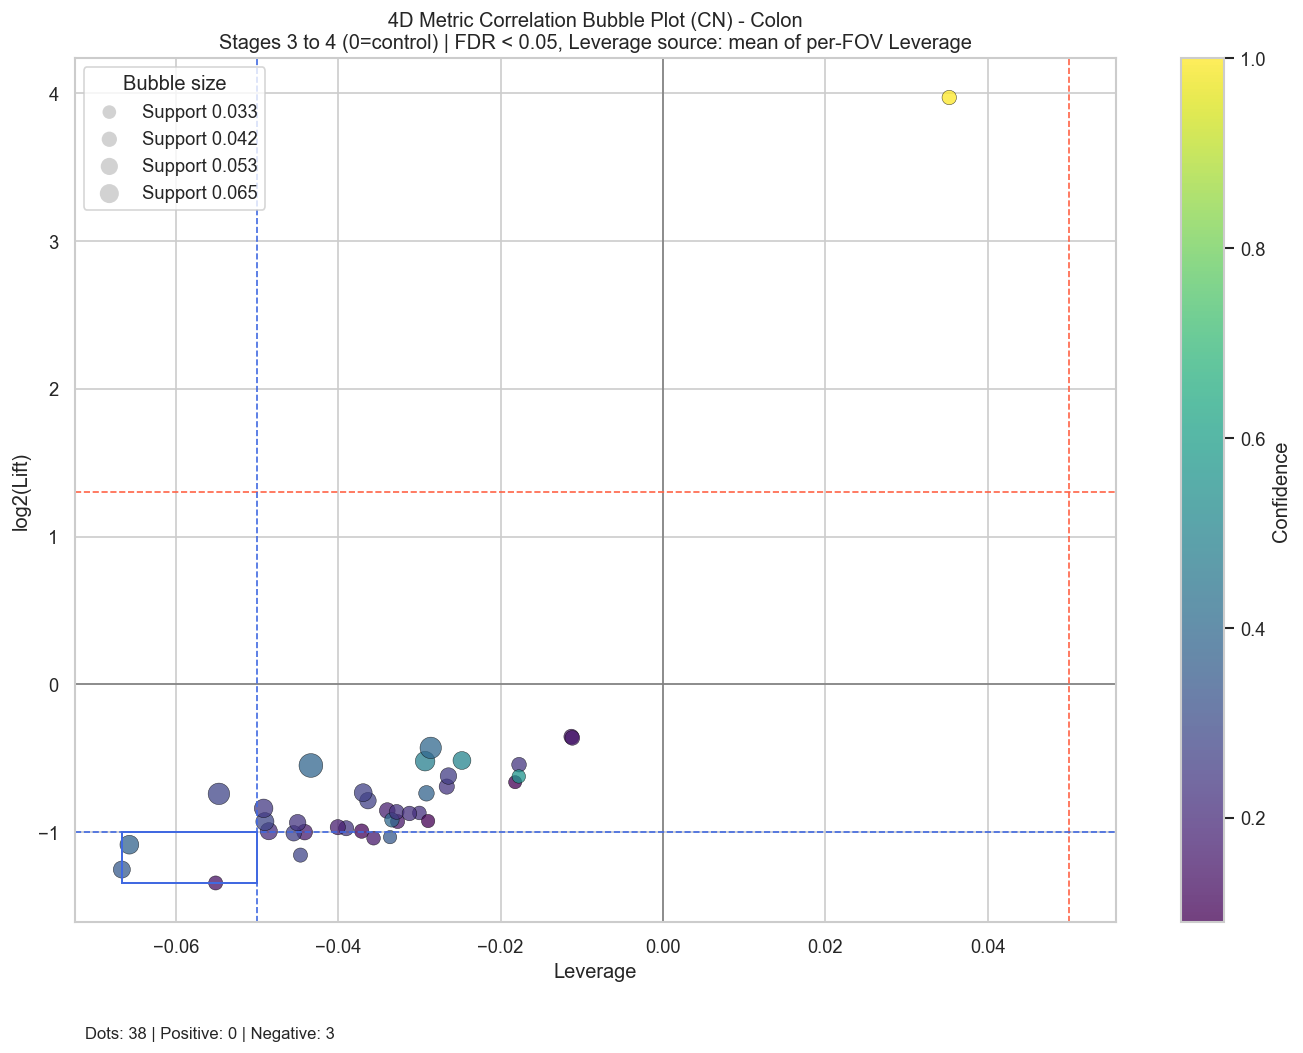

In [135]:
STAGE_MIN = 3   # 0 is control
STAGE_MAX = 4
ORGAN = "Colon"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()


Initial rules count: 209516
Rules count after filtering by subset rule items: 5130
Rules count after filtering by minimum support: 1158
Rules count after filtering by minimum stage: 231
Rules count after filtering by stage: 231
Rules count after filtering by organ: 132
metric_df number of lines: 122
filtered work_df: (132, 30)
metric_df (after FDR + metric filters): (56, 8)
leverage_source: mean of per-FOV Leverage
                           Rule      Lift  Confidence   Support  Leverage  \
0  BrunnerGland -> BrunnerGland  4.969567    0.941649  0.081010  0.062600   
1    BrunnerGland -> Fibroblast  0.475593    0.350750  0.033520 -0.036961   
2    BrunnerGland -> Macrophage  0.534240    0.446829  0.038370 -0.033242   
3            CD4T -> Epithelial  0.642540    0.168025  0.038808 -0.021590   
4            Epithelial -> CD4T  0.646226    0.344453  0.038478 -0.021824   
5            Epithelial -> CD8T  0.497522    0.209596  0.034250 -0.034591   
6      Epithelial -> Fibroblast  0.576230 

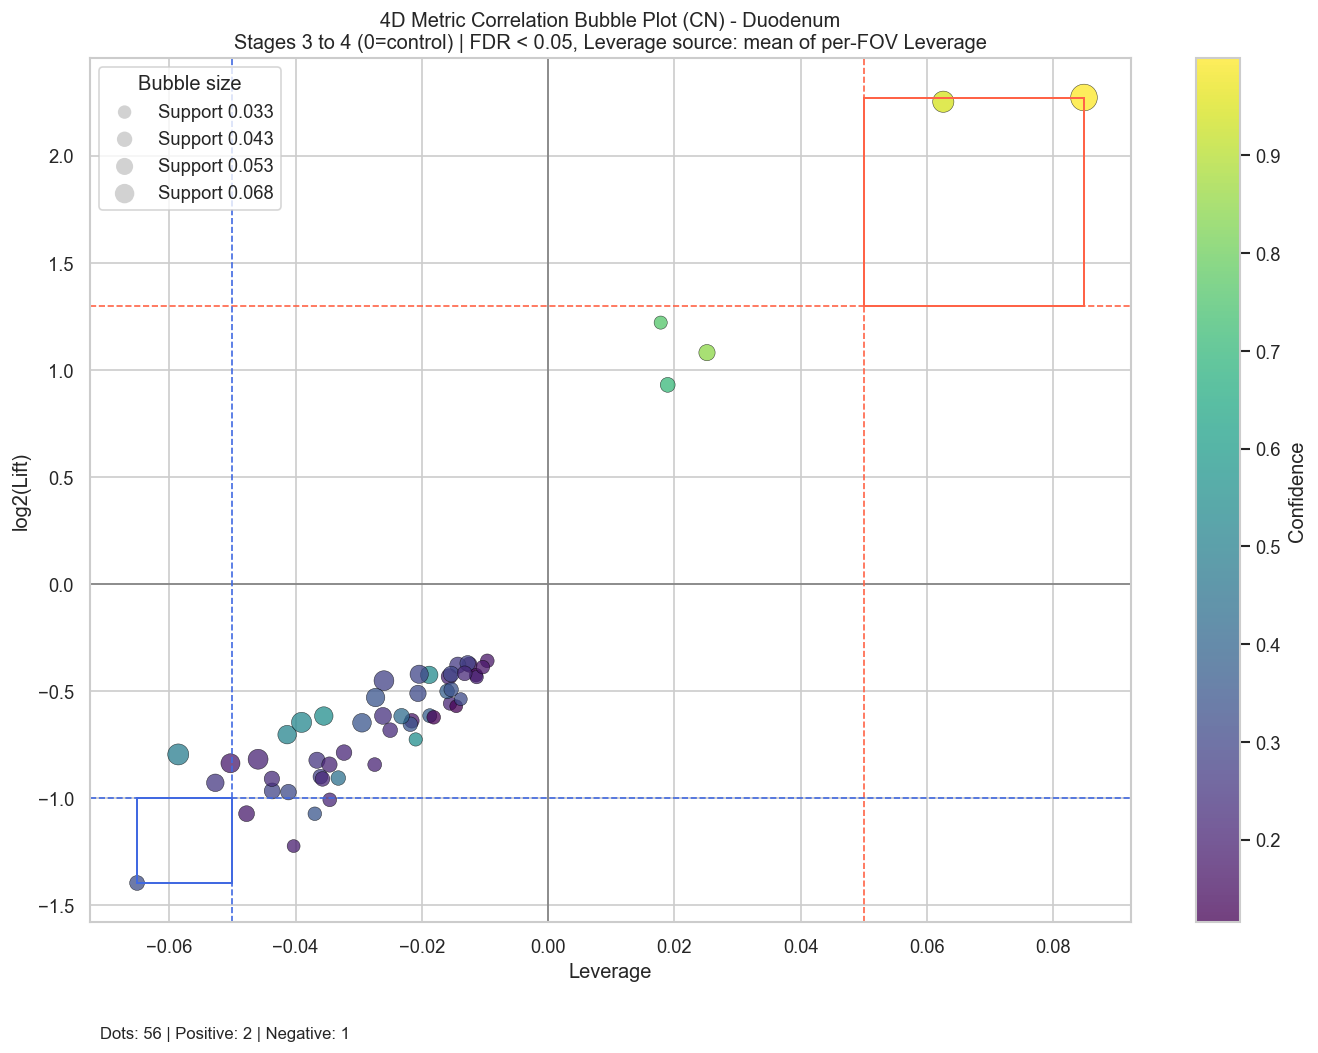

In [136]:
STAGE_MIN = 3   # 0 is control
STAGE_MAX = 4
ORGAN = "Duodenum"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()
